<a href="https://colab.research.google.com/github/rininuruls/Tugas-BigData-Sesi-12/blob/main/Big_Data_Case_Assigment_12_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Top 10 frequent keywords in best sellers:
 laptop    29
ssd       15
11        12
i5        11
intel     11
14        11
lenovo    11
i7        10
ram       10
core      10
dtype: int64


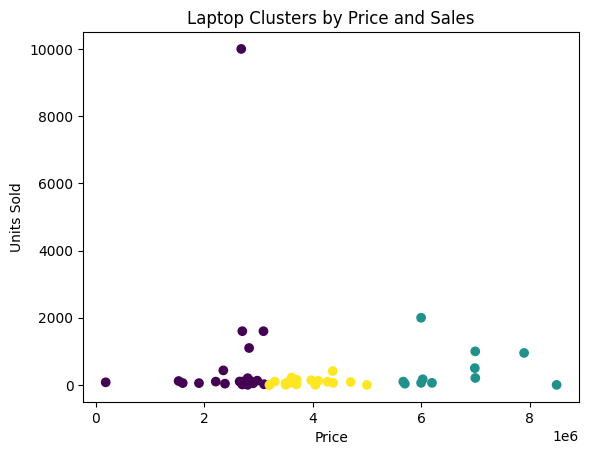

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.feature_extraction.text import CountVectorizer

# Load and clean data
df = pd.read_excel("Laptop___1719332569.xlsx", sheet_name="SheetJS")
df['Price'] = df['Price'].str.replace('.', '', regex=False).astype(int)

def parse_sell(s):
    if pd.isna(s): return np.nan
    s = s.lower().replace('terjual', '').replace('+', '').strip()
    if 'rb' in s:
        return float(s.replace('rb', '').replace(',', '.')) * 1000
    return float(s.replace(',', ''))

df['Sell'] = df['Sell'].apply(parse_sell)

# Drop rows with missing sell data
df = df.dropna(subset=['Sell'])

# Clustering based on Price & Sell
X = df[['Price', 'Sell']]
kmeans = KMeans(n_clusters=3, random_state=0)
df['Cluster'] = kmeans.fit_predict(X)

# Regression
model = LinearRegression()
model.fit(df[['Price']], df['Sell'])
df['Predicted_Sell'] = model.predict(df[['Price']])

# Frequent title words in top-selling laptops
high_sellers = df[df['Sell'] > df['Sell'].median()]
vectorizer = CountVectorizer(stop_words='english')
X_title = vectorizer.fit_transform(high_sellers['Title'])
word_freq = pd.DataFrame(X_title.toarray(), columns=vectorizer.get_feature_names_out()).sum().sort_values(ascending=False)

# Show top 10 frequent words
print("Top 10 frequent keywords in best sellers:\n", word_freq.head(10))

# Plot clustering
plt.scatter(df['Price'], df['Sell'], c=df['Cluster'], cmap='viridis')
plt.xlabel("Price")
plt.ylabel("Units Sold")
plt.title("Laptop Clusters by Price and Sales")
plt.show()

Accuracy: 0.18181818181818182

Classification Report:
               precision    recall  f1-score   support

           0       0.14      0.25      0.18         4
           1       0.25      0.14      0.18         7

    accuracy                           0.18        11
   macro avg       0.20      0.20      0.18        11
weighted avg       0.21      0.18      0.18        11



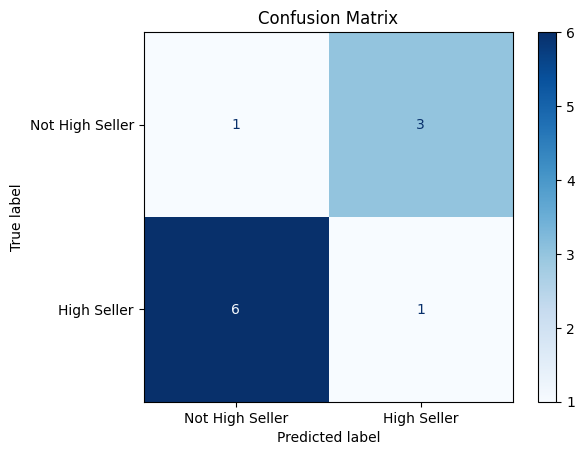

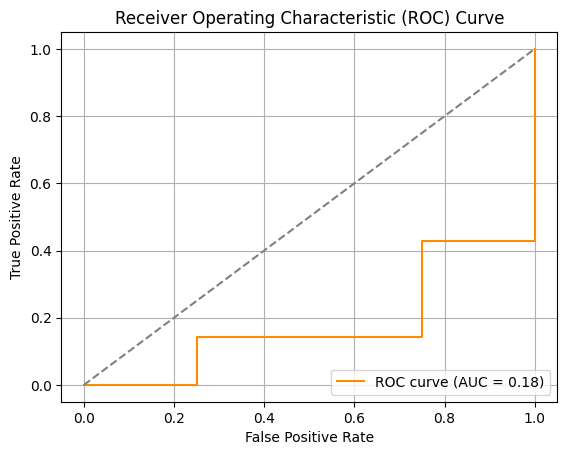

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# Create target column: High Seller (1) or Not (0)
df['High_Seller'] = (df['Sell'] > df['Sell'].median()).astype(int)

# Feature engineering: Use Price and title word counts as features
vectorizer = CountVectorizer(stop_words='english', max_features=20)
title_features = vectorizer.fit_transform(df['Title']).toarray()
title_df = pd.DataFrame(title_features, columns=vectorizer.get_feature_names_out())

# Combine with Price
features = pd.concat([df[['Price']].reset_index(drop=True), title_df], axis=1)

# Standardize features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(features_scaled, df['High_Seller'], test_size=0.2, random_state=42)

# Classification model
clf = LogisticRegression()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not High Seller', 'High Seller'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# ROC Curve
y_prob = clf.predict_proba(X_test)[:, 1]  # Probability estimates for positive class
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid()
plt.show()

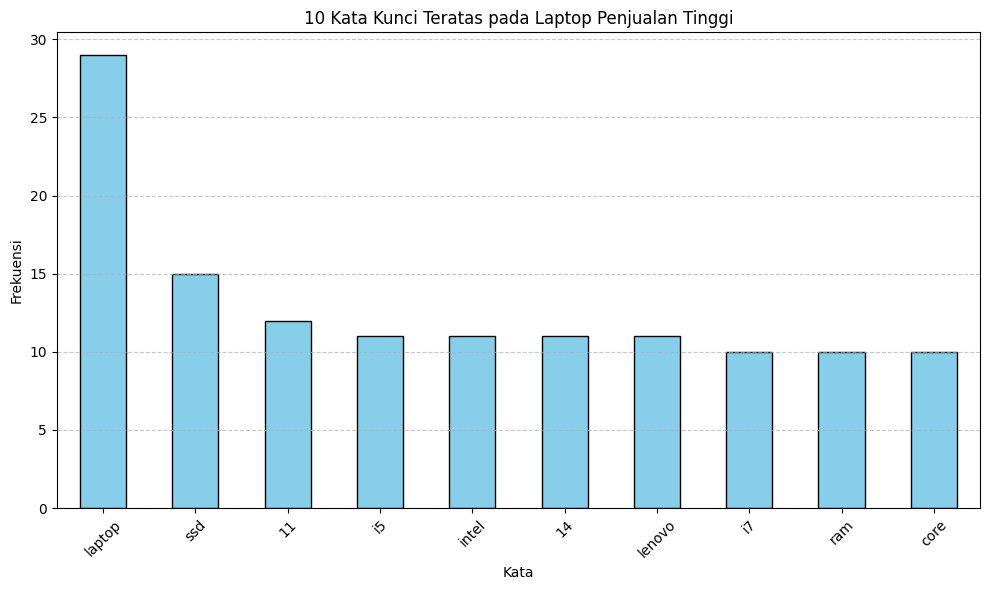

In [ ]:
# Bar chart untuk 10 kata kunci teratas dari laptop dengan penjualan tinggi
top_words = word_freq.head(10)

plt.figure(figsize=(10, 6))
top_words.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("10 Kata Kunci Teratas pada Laptop Penjualan Tinggi")
plt.xlabel("Kata")
plt.ylabel("Frekuensi")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

